<a href="https://colab.research.google.com/github/Siddwayy/data-visualization-projects/blob/main/Assignment2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Question1

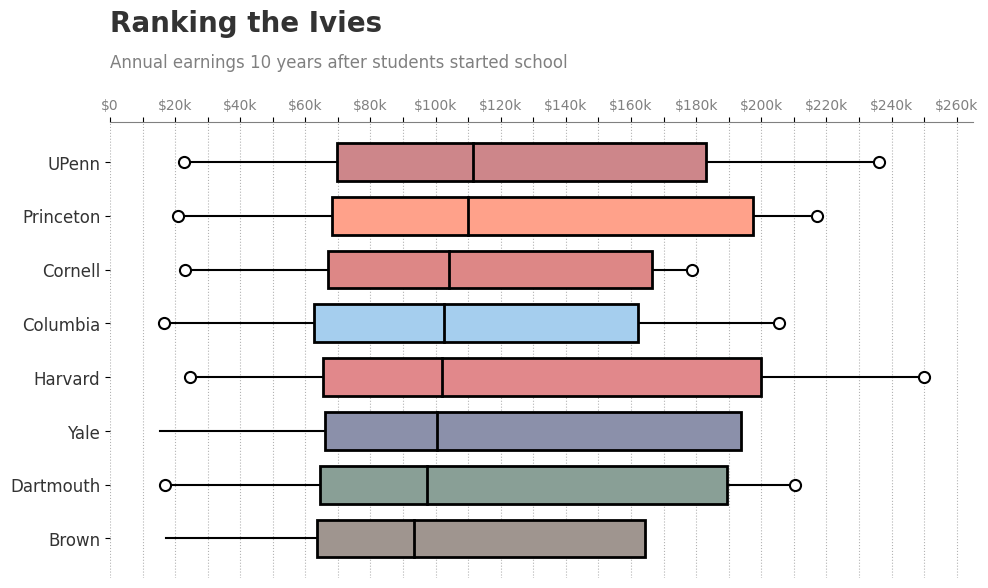

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Map long institution names to short labels
school_map = {
    'Brown University': 'Brown',
    'Columbia University in the City of New York': 'Columbia',
    'Cornell University': 'Cornell',
    'Dartmouth College': 'Dartmouth',
    'Harvard University': 'Harvard',
    'University of Pennsylvania': 'UPenn',
    'Princeton University': 'Princeton',
    'Yale University': 'Yale'
}

# Define specific brand colors for the plot
colors = {
    'Harvard': '#E1888B', 'UPenn': '#CD868A', 'Princeton': '#FFA18A',
    'Columbia': '#A5CEEE', 'Cornell': '#DD8786', 'Dartmouth': '#899F96',
    'Yale': '#8B90AA', 'Brown': '#9F958F'
}

# Load data and filter for Ivy League schools
df = pd.read_csv('college-earnings.csv')
df['School'] = df['INSTNM'].map(school_map)
df = df.dropna(subset=['School'])

# Convert earnings columns to numeric values
cols = ['MD_EARN_WNE_P10', 'PCT10_EARN_WNE_P10', 'PCT25_EARN_WNE_P10',
        'PCT75_EARN_WNE_P10', 'PCT90_EARN_WNE_P10']
for col in cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Sort schools by median earnings
df = df.sort_values('MD_EARN_WNE_P10')

# Initialize the plot
fig, ax = plt.subplots(figsize=(10, 6))

# Custom draw each "box and whisker" row
for i, row in enumerate(df.itertuples()):
    p10, p25 = row.PCT10_EARN_WNE_P10, row.PCT25_EARN_WNE_P10
    median = row.MD_EARN_WNE_P10
    p75, p90 = row.PCT75_EARN_WNE_P10, row.PCT90_EARN_WNE_P10
    color = colors[row.School]
    y = i

    # Draw horizontal whisker (10th to 90th percentile)
    ax.plot([p10, p90], [y, y], color='black', linewidth=1.5, zorder=1)

    # Draw the main box (25th to 75th percentile)
    rect = patches.Rectangle(
        xy=(p25, y - 0.35),
        width=(p75 - p25),
        height=0.7,
        facecolor=color,
        edgecolor='black',
        linewidth=2,
        zorder=2
    )
    ax.add_patch(rect)

    # Draw vertical median line
    ax.plot([median, median], [y - 0.35, y + 0.35], color='black', linewidth=2, zorder=3)

    # Add end-cap circles for all schools except Yale and Brown
    if row.School not in ['Yale', 'Brown']:
        ax.plot([p10, p90], [y, y], 'o', color='white', markeredgecolor='black',
                markeredgewidth=1.5, markersize=8, zorder=4)

# Configure Y-axis labels
ax.set_yticks(range(len(df)))
ax.set_yticklabels(df['School'], fontsize=12, color='#333333')

# Format X-axis with currency labels every $20k
ticks = list(range(0, 270000, 10000))
labels = [f"${int(t/1000)}k" if (t % 20000 == 0 and t > 0) else "$0" if t == 0 else "" for t in ticks]

ax.set_xticks(ticks)
ax.set_xticklabels(labels, color='grey', fontsize=10)
ax.xaxis.tick_top() # Move labels to top
ax.set_xlim(0, 265000)

# Add styling and remove unnecessary borders
ax.grid(axis='x', linestyle=':', color='black', alpha=0.3)
ax.set_axisbelow(True)
ax.spines['left'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['top'].set_color('grey')

# Add titles
plt.text(0, 1.20, "Ranking the Ivies", transform=ax.transAxes, fontsize=20, weight='bold', color='#333333')
plt.text(0, 1.12, "Annual earnings 10 years after students started school", transform=ax.transAxes, fontsize=12, color='grey')

plt.tight_layout()
plt.show()

Some of the code used in the visualization was referred from the following documentation.

* `df[col] = pd.to_numeric(df[col], errors='coerce')`
[Source Link](https://pandas.pydata.org/docs/reference/api/pandas.to_numeric.html)
* `df = df.sort_values('MD_EARN_WNE_P10')`
[Source Link](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.sort_values.html)
* `rect = patches.Rectangle(...)`
[Source Link](https://matplotlib.org/stable/api/_as_gen/matplotlib.patches.Rectangle.html)
* `ax.add_patch(rect)`
[Source Link](https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.add_patch.html)
* `ax.plot([p10, p90], [y, y], ...)`
[Source Link](https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.plot.html)
* `ax.set_yticks(range(len(df)))`
[Source Link](https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.set_yticks.html)
* `ax.set_xticks(ticks)`
[Source Link](https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.set_xticks.html)
* `ax.xaxis.tick_top()`
[Source Link](https://matplotlib.org/stable/api/_as_gen/matplotlib.axis.XAxis.tick_top.html)
* `ax.grid(axis='x', ...)`
[Source Link](https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.grid.html)
* `ax.spines['left'].set_visible(False)`
[Source Link](https://www.google.com/search?q=https://matplotlib.org/stable/api/spines_api.html%23matplotlib.spines.Spine.set_visible)
* `plt.text(0, 1.20, ...)`
[Source Link](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.text.html)
* `plt.show()`
[Source Link](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.show.html)

Question2

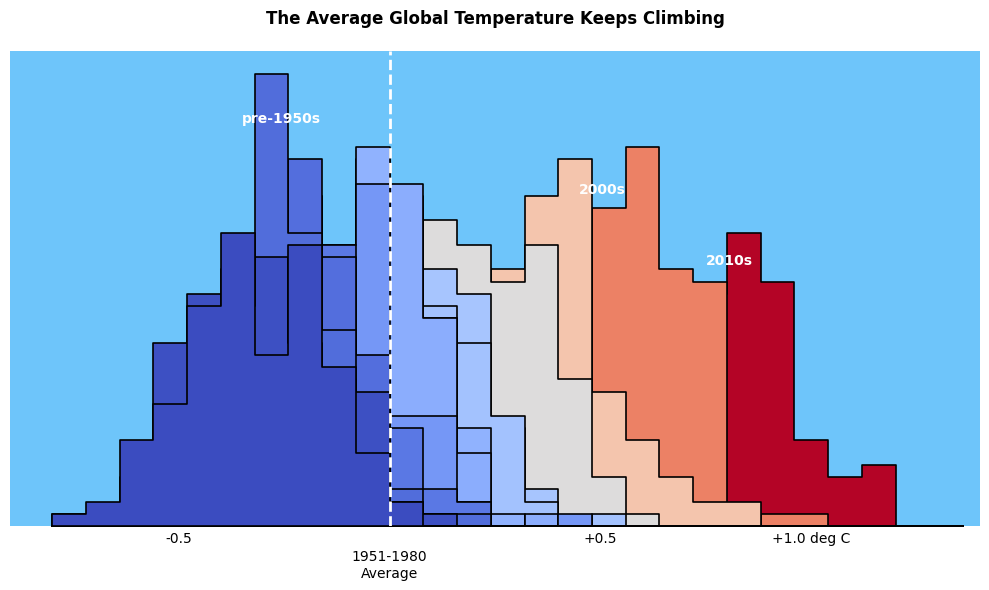

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Prepare Data
df = pd.read_csv('temps.csv')
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

# Pivot the data from wide format (months as columns) to long format (rows for each month)
df = df.melt(id_vars='Year', value_vars=months, var_name='Month', value_name='Temp')

# Group years into 10-year chunks and filter the range
df['Decade'] = (df['Year'] // 10) * 10
df = df[(df['Decade'] >= 1880) & (df['Decade'] <= 2010)]

# Calculate average temp per decade to determine the plotting order and color intensity
decade_stats = df.groupby('Decade')['Temp'].mean().sort_values()
decades = decade_stats.index

# Setup Colors
# Normalize temperature values to map them to the 'coolwarm' (blue-to-red) color map
norm = plt.Normalize(decade_stats.min(), decade_stats.max())
cmap = plt.get_cmap('coolwarm')
palette = {d: cmap(norm(temp)) for d, temp in decade_stats.items()}

# Plot
fig, ax = plt.subplots(figsize=(10, 6), facecolor='white')
ax.set_facecolor('#6EC5FA') # Sky blue background

# Create a stepped histogram (joyplot style) for temperature distributions
sns.histplot(
    data=df, x='Temp', hue='Decade', hue_order=decades, palette=palette,
    bins=np.arange(-0.8, 1.4, 0.08), element="step", fill=True, alpha=1.0,
    edgecolor='black', linewidth=1.2, legend=False, common_norm=False, ax=ax
)

# Styling & Annotations
# Add a vertical reference line at 0 degrees anomaly
ax.axvline(0, color='white', linestyle='--', linewidth=2)
sns.despine(ax=ax, left=True, bottom=True, right=True, top=True)

# Clean up axes and format labels
ax.set(yticks=[], ylabel='', xlabel='', xlim=(-0.9, 1.4), xticks=[-0.5, 0, 0.5, 1])
ax.set_xticklabels(['-0.5', '', '+0.5', '+1.0 deg C'])
ax.tick_params(length=0)

# Add titles and baseline reference text
ax.set_title('The Average Global Temperature Keeps Climbing', fontweight='bold', pad=20)
ax.text(0, -0.05, '1951-1980\nAverage', ha='center', va='top', transform=ax.get_xaxis_transform())

# Place manual labels for specific eras in the chart area
y_top = ax.get_ylim()[1]
style = {'color': 'white', 'weight': 'bold', 'fontsize': 10}
ax.text(-0.35, y_top * 0.85, 'pre-1950s', **style)
ax.text(0.45, y_top * 0.70, '2000s', **style)
ax.text(0.75, y_top * 0.55, '2010s', **style)

plt.tight_layout()
plt.show()